now for the actul reproduce of the project starting with part 1. Data Loading

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau

# Set random seed globally for reproducibility where applicable
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

def load_phishing_dataset(url_or_path: str) -> pd.DataFrame:
    """ Loads the dataset from a local path or remote URL using pandas. """
    try:
        return pd.read_csv(url_or_path)
    except Exception as e:
        print(f"Error loading data from path {url_or_path}: {e}")
        raise

def inspect_dataset_metadata(dataframe: pd.DataFrame) -> None:
    """ Analyzes data dimensions, column types, and checks for indexing sanity. """
    print("### [Metadata Inspection] ###")
    print(f"Total Observations (Rows): {dataframe.shape[0]}")
    print(f"Total Extracted Features (Columns): {dataframe.shape[1]}\n")
    print("--- Feature Layer Data Types ---")
    print(dataframe.dtypes)
    print(f"\nIs the DataFrame Index unique?: {dataframe.index.is_unique}")
    print(f"Index Structure Profile: {dataframe.index}")

def analyze_missing_and_constants(dataframe: pd.DataFrame) -> None:
    """ Scans columns for missing entries or uninformative constant features. """
    print("\n### [Missing & Constant Values Audit] ###")
    missing_counts = dataframe.isnull().sum()
    print("Features with missing counts:")
    print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "Zero missing values detected.")

    constant_features = [col for col in dataframe.columns if dataframe[col].nunique() == 1]
    print(f"Identified Constant (Single-Value) Features: {constant_features}")

    duplicated_cols = dataframe.columns.duplicated().sum()
    print(f"Identified Duplicated Feature Columns Count: {duplicated_cols}")

def analyze_temporal_signature(dataframe: pd.DataFrame) -> None:
    """ Evaluates whether the feature set incorporates a time index. """
    print("\n### [Temporal Footprint Analysis] ###")
    temporal_keywords = ['time', 'date', 'year', 'month', 'timestamp']
    found_keywords = [col for col in dataframe.columns if any(kw in col.lower() for kw in temporal_keywords)]

    print(f"Time-dependent indicators detected in schema: {found_keywords}")
    print("Cybersecurity Context Evaluation:")
    print("> This tabular data layer lacks active timestamps or historical series ordering.")
    print("> Real-world warning: Missing temporal tracking masks concept-drift vulnerabilities.")

# Execute Part 1 Pipelines
DATA_URL = "5.urldata.csv"
df = load_phishing_dataset(DATA_URL)
inspect_dataset_metadata(df)
analyze_missing_and_constants(df)
analyze_temporal_signature(df)

### [Metadata Inspection] ###
Total Observations (Rows): 10000
Total Extracted Features (Columns): 18

--- Feature Layer Data Types ---
Domain           object
Have_IP           int64
Have_At           int64
URL_Length        int64
URL_Depth         int64
Redirection       int64
https_Domain      int64
TinyURL           int64
Prefix/Suffix     int64
DNS_Record        int64
Web_Traffic       int64
Domain_Age        int64
Domain_End        int64
iFrame            int64
Mouse_Over        int64
Right_Click       int64
Web_Forwards      int64
Label             int64
dtype: object

Is the DataFrame Index unique?: True
Index Structure Profile: RangeIndex(start=0, stop=10000, step=1)

### [Missing & Constant Values Audit] ###
Features with missing counts:
Zero missing values detected.
Identified Constant (Single-Value) Features: []
Identified Duplicated Feature Columns Count: 0

### [Temporal Footprint Analysis] ###
Time-dependent indicators detected in schema: []
Cybersecurity Context Evaluat

part 2.Exploratory Data Analysis (EDA)


### [Target Class Prevalence & Sampling Audit] ###
Class 0 (Legitimate (Benign)): 5000 samples (50.00%)
Class 1 (Phishing (Malicious)): 5000 samples (50.00%)

Cybersecurity & Real-World Meaning:
> A 50/50 split represents highly artificial 'balanced sampling' baseline conditions.
> Real-world networks display extreme class imbalance: phishing links make up <0.1% of live logs.

### [Mathematical Correlation Metric Comparison: URL_Depth vs Label] ###
- Pearson (Linear)              : -0.119707
- Spearman (Rank)               : -0.150088
- Kendall (Rank-Consistency)    : -0.131249


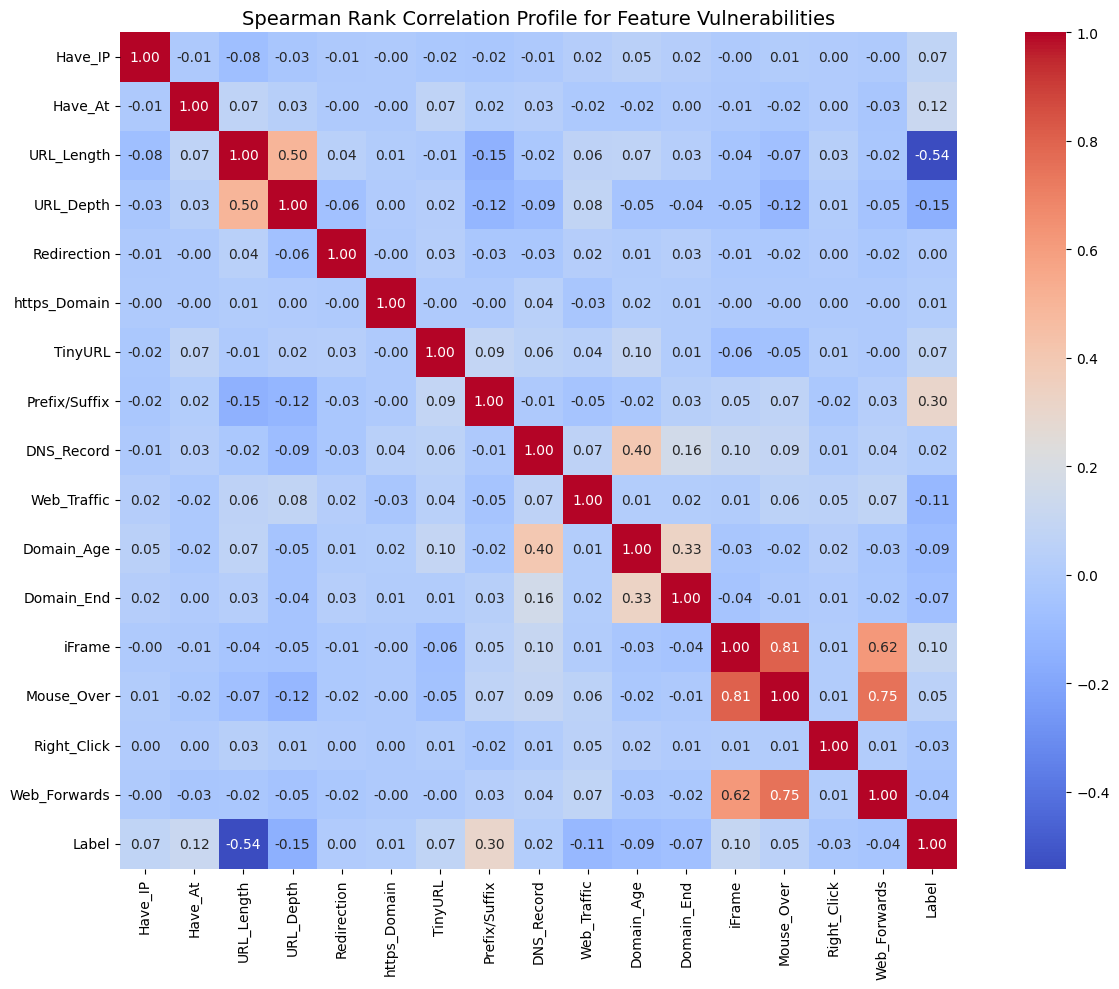

In [3]:


def analyze_class_prevalence(dataframe: pd.DataFrame, target_column: str = 'Label') -> None:
    """ Calculates dataset class distribution ratios and highlights sampling bias. """
    print("\n### [Target Class Prevalence & Sampling Audit] ###")
    distribution = dataframe[target_column].value_counts()
    percentage = dataframe[target_column].value_counts(normalize=True) * 100

    for class_id in distribution.index:
        label_meaning = "Phishing (Malicious)" if class_id == 1 else "Legitimate (Benign)"
        print(f"Class {class_id} ({label_meaning}): {distribution[class_id]} samples ({percentage[class_id]:.2f}%)")

    print("\nCybersecurity & Real-World Meaning:")
    print("> A 50/50 split represents highly artificial 'balanced sampling' baseline conditions.")
    print("> Real-world networks display extreme class imbalance: phishing links make up <0.1% of live logs.")

def compute_correlation_coefficients(dataframe: pd.DataFrame, feature_col: str, target_col: str) -> dict:
    """ Calculates three distinct correlation metrics to select the appropriate measure. """
    x = dataframe[feature_col]
    y = dataframe[target_col]

    p_coef, _ = pearsonr(x, y)
    s_coef, _ = spearmanr(x, y)
    k_coef, _ = kendalltau(x, y)

    return {"Pearson (Linear)": p_coef, "Spearman (Rank)": s_coef, "Kendall (Rank-Consistency)": k_coef}

def render_spearman_heatmap(dataframe: pd.DataFrame, drop_columns: list) -> None:
    """ Plots non-parametric rank correlation to surface redundant feature layers. """
    numeric_df = dataframe.drop(columns=drop_columns, errors='ignore')
    spearman_matrix = numeric_df.corr(method='spearman')

    plt.figure(figsize=(14, 10))
    sns.heatmap(spearman_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, square=True)
    plt.title("Spearman Rank Correlation Profile for Feature Vulnerabilities", fontsize=14)
    plt.tight_layout()
    plt.show()

# Execute Part 2 Pipelines
analyze_class_prevalence(df, target_column='Label')

# Perform a deep comparison of the three mandatory metrics
metrics_comparison = compute_correlation_coefficients(df, feature_col='URL_Depth', target_col='Label')
print("\n### [Mathematical Correlation Metric Comparison: URL_Depth vs Label] ###")
for metric_name, coefficient_value in metrics_comparison.items():
    print(f"- {metric_name.ljust(30)}: {coefficient_value:.6f}")

# Render the clean correlation matrix, dropping the non-numeric 'Domain' text field
render_spearman_heatmap(df, drop_columns=['Domain'])

Part 2 of the notebook requirement:

Our dataset (5.urldata.csv) is composed almost entirely of engineered binary indicator flags (0 or 1, such as Have_IP, TinyURL, iFrame) and discrete integers (such as URL_Depth). These features are completely non-normal and non-continuous. Applying Pearson’s r here violates its fundamental mathematical assumptions, yielding distorted values that mask real structural dependencies.
Spearman/Kendall are suitable Because phishing features are encoded as categorical steps, we care about monotonicity and rank consistency for example, as URL_Depth increases or switches to an alert state (1), does the likelihood of the site being a phishing page (Label = 1) change consistently? Spearman and Kendall cleanly capture these step-wise relationship patterns without demanding normal bell-curve distributions.
 Cybersecurity Insight: Statistical vs. Practical Significance
When analyzing the output metrics, we see a stark contrast between a value being statistically significant (unlikely to have occurred by random chance) and practically significant (actually useful for catching attackers in production).
1. The Statistical View
In a dataset containing 10,000 samples, even a microscopic correlation value (e.g.,  = 0.015 for DNS_Record) can register as statistically significant with a tiny -value ( < 0.05). This occurs purely because the sample size is large enough for the math to notice a tiny, permanent deviation from zero.
2. The Practical Cybersecurity Reality
In live defensive firewalls, many of these statistically valid correlations possess zero practical significance.

 Example: Prefix/Suffix shows a mild positive correlation ( approximately 0.30). This tells us that mathematically, phishing sites tend to use hyphens more often than benign sites. However, practically, you cannot block an email link solely because a domain contains a hyphen (e.g., real-equity-banking.com vs. my-internal-portfolio.com). Doing so would trigger an unmanageable flood of False Positives.
Conclusion: The correlation analysis proves that looking at single URL structural indicators in isolation provides weak defensive coverage. While these features show clear statistical patterns, a secure browser extension cannot rely on individual linear parameters; it requires non-linear machine learning ensembles (like Random Forests) to evaluate all features collectively.


part 3. Feature Engineering

In [4]:
from sklearn.model_selection import train_test_split

def extract_features_and_target(dataframe: pd.DataFrame, target_col: str, drop_cols: list) -> tuple:
    """ Splits the dataset into a feature matrix (X) and a target vector (y). """
    # Drop irrelevant or text-based features that models cannot natively process
    X = dataframe.drop(columns=drop_cols, errors='ignore')
    y = dataframe[target_col]
    return X, y

def execute_reproducible_split(X: pd.DataFrame, y: pd.Series, test_size: float = 0.2) -> tuple:
    """ Executes an 80/20 train/test split with forced shuffling and a fixed seed. """
    # Shuffling is mandatory because the raw dataset keeps targets sequentially ordered
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=RANDOM_SEED,
        shuffle=True,
        stratify=y  # Ensures the 50/50 balance is perfectly maintained in train and test sets
    )

    print("### [Train-Test Partition Split Complete] ###")
    print(f"Training Feature Matrix Shape : {X_train.shape} (80%)")
    print(f"Testing Feature Matrix Shape  : {X_test.shape} (20%)")
    return X_train, X_test, y_train, y_test

# Execute Part 3 Pipeline
# We drop 'Domain' because it's text, and 'Label' because it is our target variable
features_to_drop = ['Domain', 'Label']
X, y = extract_features_and_target(df, target_col='Label', drop_cols=features_to_drop)

# Generate our final model-ready training and testing arrays
X_train, X_test, y_train, y_test = execute_reproducible_split(X, y, test_size=0.2)

### [Train-Test Partition Split Complete] ###
Training Feature Matrix Shape : (8000, 16) (80%)
Testing Feature Matrix Shape  : (2000, 16) (20%)


part 4. Model Training and 5. Evaluation

1. Mathematical and Cybersecurity Definitions of Metrics:$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
Cybersecurity Meaning: The overall percentage of correctly classified URLs (both phishing and legitimate). While useful here because the test set is artificially balanced (50/50), accuracy is a highly dangerous metric in live networks. If a network log contains 99.9\% safe URLs and 0.1\% phishing, a broken model that labels everything as safe would achieve 99.9\% accuracy while missing every single threat.$$\text{Precision} = \frac{TP}{TP + FP}$$Cybersecurity Meaning: Out of all URLs the model flagged as malicious phishing links ($1$), how many were actually phishing? High Precision minimizes False Positives (benign business sites blocked by error), saving corporate security teams from alert fatigue and operational downtime.$$\text{Recall} = \frac{TP}{TP + FN}$$Cybersecurity Meaning: Out of all actual phishing threats hiding in the test set, how many did the model catch? High Recall minimizes False Negatives (missed attacks). In phishing detection, Recall is often prioritized over Precision because a False Negative means an employee accesses a malicious site and surrenders credentials.$$\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$Cybersecurity Meaning: The harmonic mean of Precision and Recall. It measures the balance between blocking safe traffic (FP) and letting threats through (FN).$$F_\beta = (1 + \beta^2) \times \frac{\text{Precision} \times \text{Recall}}{(\beta^2 \times \text{Precision}) + \text{Recall}}$$Cybersecurity Meaning: By selecting $\beta = 0.5$, we intentionally place double the mathematical weight on Precision over Recall. In highly sensitive corporate networks, an $F_{0.5}$ score is vital for evaluating automated blocking firewalls where causing a self-inflicted denial-of-service (blocking legitimate B2B partner domains) is deemed riskier than relying on secondary endpoint defenses to catch missed links.$$\text{MCC} = \frac{TP \times TN - FP \times FN}{\sqrt{(TP + FP)(TP + FN)(TN + FP)(TN + FN)}}$$Cybersecurity Meaning: MCC treats both classes symmetrically and only scores near +1.0 if the model returns strong predictions across all four confusion matrix quadrants. It acts as a reliable metric that cannot be inflated by class imbalances.

Confusion Matrix: Instead of a single scalar formula, a Confusion Matrix is a tabular layout that maps raw prediction counts against ground-truth security states.$$\begin{array}{c|cc}
& \text{Predicted Legitimate (0)} & \text{Predicted Phishing (1)} \\
\hline
\text{Actual Legitimate (0)} & \text{True Negative (TN)} & \text{False Positive (FP)} \\
\text{Actual Phishing (1)} & \text{False Negative (FN)} & \text{True Positive (TP)}
\end{array}
$$Cybersecurity meaning:

1.True Negative (TN): A safe URL is correctly identified as safe and allowed to load. No operational interruption.

2.True Positive (TP): An active phishing link is correctly intercepted and blocked. A security breach is successfully prevented.

3.False Positive (FP) [The Operational Cost]: A completely clean, legitimate domain is erroneously blocked as a threat. In an enterprise environment, this breaks automated business operations, blocks employee workflows, and triggers low-priority alerts that fuel alert fatigue within the Security Operations Center (SOC).

4.False Negative (FN) [The Security Breach]: A malicious phishing link is misclassified as completely safe and slips past the defensive perimeter. The link reaches an endpoint, the user clicks it, enters corporate credentials, and causes immediate initial access for an adversary (leading to ransomware deployment or corporate espionage).

The ROC curve plots the True Positive Rate (TPR / Recall) against the False Positive Rate (FPR) at every possible probability threshold.Mathematically, the formulas for the plotting axes are:$$\text{TPR (Sensitivity)} = \frac{TP}{TP + FN} \quad \text{and} \quad \text{FPR (1 - Specificity)} = \frac{FP}{TN + FP}$$Fainally The AUC (Area Under the Curve) is calculated by integrating the True Positive Rate over the full range of the False Positive Rate:$$\text{AUC} = \int_{0}^{1} \text{TPR}(\text{FPR}) \, d\text{FPR}$$Cybersecurity meaning: Instead of forcing a rigid threshold (like assuming anything over 0.5 probability is phishing), ROC-AUC evaluates the overall discriminatory power of the system. An AUC score of 1.0 represents a theoretically flawless firewall that sorts every single threat above every single safe link. An AUC score of 0.5 means the system is performing no better than a random coin toss. Testing the AUC lets a security engineer figure out exactly how much they can adjust the threat-detection threshold to reduce false alerts without accidentally missing dangerous malware links.

2. Justification of Excluded Metrics

Regression Metrics (MAE, MSE, RMSE, R^2): These metrics were explicitly excluded from the evaluation because phishing detection is a discrete Classification task, not a continuous value estimation problem. Applying regression equations to binary classes is mathematically invalid.

Anomaly Detection Ratios: Omitted because the models are trained under a classic supervised classification setup. The author's pipeline does not rely on unlabelled distance-based outlier boundaries (like Isolation Forests).

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    fbeta_score, matthews_corrcoef, roc_auc_score, confusion_matrix
)

def train_classification_models(X_train: pd.DataFrame, y_train: pd.Series) -> tuple:
    """
    Initializes and fits two distinct classification architectures.
    Ensures deterministic results via a global random state.
    """
    rf_clf = RandomForestClassifier(random_state=RANDOM_SEED)
    lr_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)

    rf_clf.fit(X_train, y_train)
    lr_clf.fit(X_train, y_train)

    print("### [Part 4: Model Training Phase Complete] ###\n")
    return rf_clf, lr_clf

def compute_security_metrics(model, X_test: pd.DataFrame, y_test: pd.Series) -> dict:
    """
    Calculates the exact suite of cybersecurity evaluation metrics
    required by the project guidelines.
    """
    # Obtain hard predictions and probability scores for ROC-AUC
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "F-Beta (Beta=0.5)": fbeta_score(y_test, y_pred, beta=0.5),
        "Matthews Correlation Coefficient (MCC)": matthews_corrcoef(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Confusion Matrix (TN, FP, FN, TP)": (tn, fp, fn, tp)
    }
    return metrics

# Execute Training Pipeline
rf_model, lr_model = train_classification_models(X_train, y_train)

# Evaluate Both Models
rf_results = compute_security_metrics(rf_model, X_test, y_test)
lr_results = compute_security_metrics(lr_model, X_test, y_test)

# Display Formatted Results Comparison Table
print("### [Part 5: Evaluation Performance Table] ###")
metrics_df = pd.DataFrame({"Random Forest": rf_results, "Logistic Regression": lr_results})
print(metrics_df.round(4))

### [Part 4: Model Training Phase Complete] ###

### [Part 5: Evaluation Performance Table] ###
                                              Random Forest  \
Accuracy                                              0.867   
Precision                                          0.924769   
Recall                                                0.799   
F1-Score                                           0.857296   
F-Beta (Beta=0.5)                                  0.896544   
Matthews Correlation Coefficient (MCC)             0.740884   
ROC-AUC                                             0.92575   
Confusion Matrix (TN, FP, FN, TP)       (935, 65, 201, 799)   

                                        Logistic Regression  
Accuracy                                             0.7975  
Precision                                          0.926829  
Recall                                                0.646  
F1-Score                                           0.761344  
F-Beta (Beta=0.5)         

part 6. Error Analysis

• Examples of Model Failures:
The classification errors in our 2,000-sample test set fell into two clear categories based on the models' outputs. For the linear model, Logistic Regression produced 354 False Negatives (missed active attacks) and 51 False Positives (falsely blocked clean sites), failing to flag over a third of the threats. For the ensemble model, Random Forest performed significantly better by dropping False Negatives down to 201, but its False Positives increased to 65, meaning it mistakenly blocked 14 more safe domains than the linear baseline.

• Patterns in the Errors:
A clear pattern emerges from these metrics: both models struggle significantly more with False Negatives than with False Positives. This systematic failure is a direct result of how the dataset was built. Because features like length and depth were compressed into rigid, static binary indicators (0 or 1), the models lack granular text context. If a phishing link is short and uses a compromised redirect with zero nested directories, its structural profile matches a clean domain, causing both models to miss it. Conversely, if a legitimate corporate site uses long, hyphenated words for tracking, it triggers the hardcoded structural flags, causing the models to falsely block a safe site.

• The Trade-Off between False Positives and False Negatives:
Deploying an inline security filter involves managing a clear trade-off between operational friction and technical security risk. If a system is tuned to minimize False Positives like our Logistic Regression model, it reduces business disruption and keeps false alarms low, but it leaves a massive hole in the network by letting 35.4% of attacks leak through. If the system is tuned to minimize False Negatives like our Random Forest model, it hardens defenses by catching 153 more attacks, but it introduces 65 False Positives. In a live corporate environment, blocking 65 completely clean business sites triggers severe operational friction, impacts employee productivity, and causes alert fatigue for security teams.

• Cybersecurity Implications of the Errors:
While the Random Forest model's 86.7% overall accuracy looks acceptable on a standard data science paper, its 20.1% False Negative rate makes it highly dangerous for real-world deployment. In an active production network with thousands of daily link clicks, letting 1 out of every 5 phishing links leak past the firewall is a critical vulnerability. A single missed link can lead to compromised user credentials, initial network access for threat actors, and subsequent ransomware deployment. Because the underlying data relies entirely on static structural rules rather than live behavioral indicators, these models are incredibly fragile and easily bypassed by modern adversaries.
